## Librerias

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency

from sklearn.feature_selection import mutual_info_classif

Lectura de los datos

In [11]:
df_raw = pd.read_csv("../data/framingham.csv")

In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [13]:
df_raw.shape

(4240, 16)

In [14]:
df_raw.head(7)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1


In [15]:
#Comprobamos cuantos nulos tiene
df_raw.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Antes de empezar con el EDA, voy a declarar las variables que están codificadas como categóricas, para que tenga sentido las gráficas.

In [18]:
df= df_raw.copy()
categoricas = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']
df[categoricas] = df[categoricas].astype('object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   object 
 1   age              4240 non-null   int64  
 2   education        4135 non-null   object 
 3   currentSmoker    4240 non-null   object 
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   object 
 6   prevalentStroke  4240 non-null   object 
 7   prevalentHyp     4240 non-null   object 
 8   diabetes         4240 non-null   object 
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   object 
dtypes: float64(7), int64(1), object(8)
memory usage: 530.1+ KB


In [31]:
numeric_cols = df.select_dtypes(exclude= 'object').columns.tolist()
categoric_cols = df.select_dtypes(include ='object').columns.tolist()
print(numeric_cols)
print("-----------------")
print(categoric_cols)

['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
-----------------
['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


Vamo a ver los estadísticos principales, para ver como primera interacción los datos. Podemos observar: que posiblemente haya outliers en las siguientes columnas (totChol, diaBP,sispBP ,hearRate y glucose,etc).

In [23]:
df.describe(percentiles=[.25,.5,.75,.95,.99]).T

,count,mean,std,min,25%,50%,75%,95%,99%,max
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,64.000,67.000,70.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,30.000,43.000,70.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,312.000,354.110,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.00,128.0,144.00,175.000,200.000,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.00,82.0,90.00,104.525,118.000,142.5
BMI,4221.0,25.800801,4.079840,15.54,23.07,25.4,28.04,32.780,38.956,56.8
heartRate,4239.0,75.878981,12.025348,44.00,68.00,75.0,83.00,98.000,110.000,143.0
glucose,3852.0,81.963655,23.954335,40.00,71.00,78.0,87.00,108.450,174.960,394.0


In [33]:
#Ver estadísticos principales de cada variable, para saber cuantos valores únicos tienen, cual es el más frecuente, etc.
df.describe(include=object).T

,count,unique,top,freq
male,4240.0,2.0,0.0,2420.0
education,4135.0,4.0,1.0,1720.0
currentSmoker,4240.0,2.0,0.0,2145.0
BPMeds,4187.0,2.0,0.0,4063.0
prevalentStroke,4240.0,2.0,0.0,4215.0
prevalentHyp,4240.0,2.0,0.0,2923.0
diabetes,4240.0,2.0,0.0,4131.0
TenYearCHD,4240.0,2.0,0.0,3596.0


Vemos el peso que tienen en el dataset de si se ha desarrollado o no

In [30]:
df['TenYearCHD'].value_counts(normalize=True)*100

TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64

## Análisis Univariable

**Columnas Categóricas**

Observamos las distribuciones de cada una de las variables numéricas y a priori podemos ver que hay outliers como hemos dicho previamente y que las distribuciones parecen ser mas o menos normales, excepto en algunas variables como por ejemplo: 

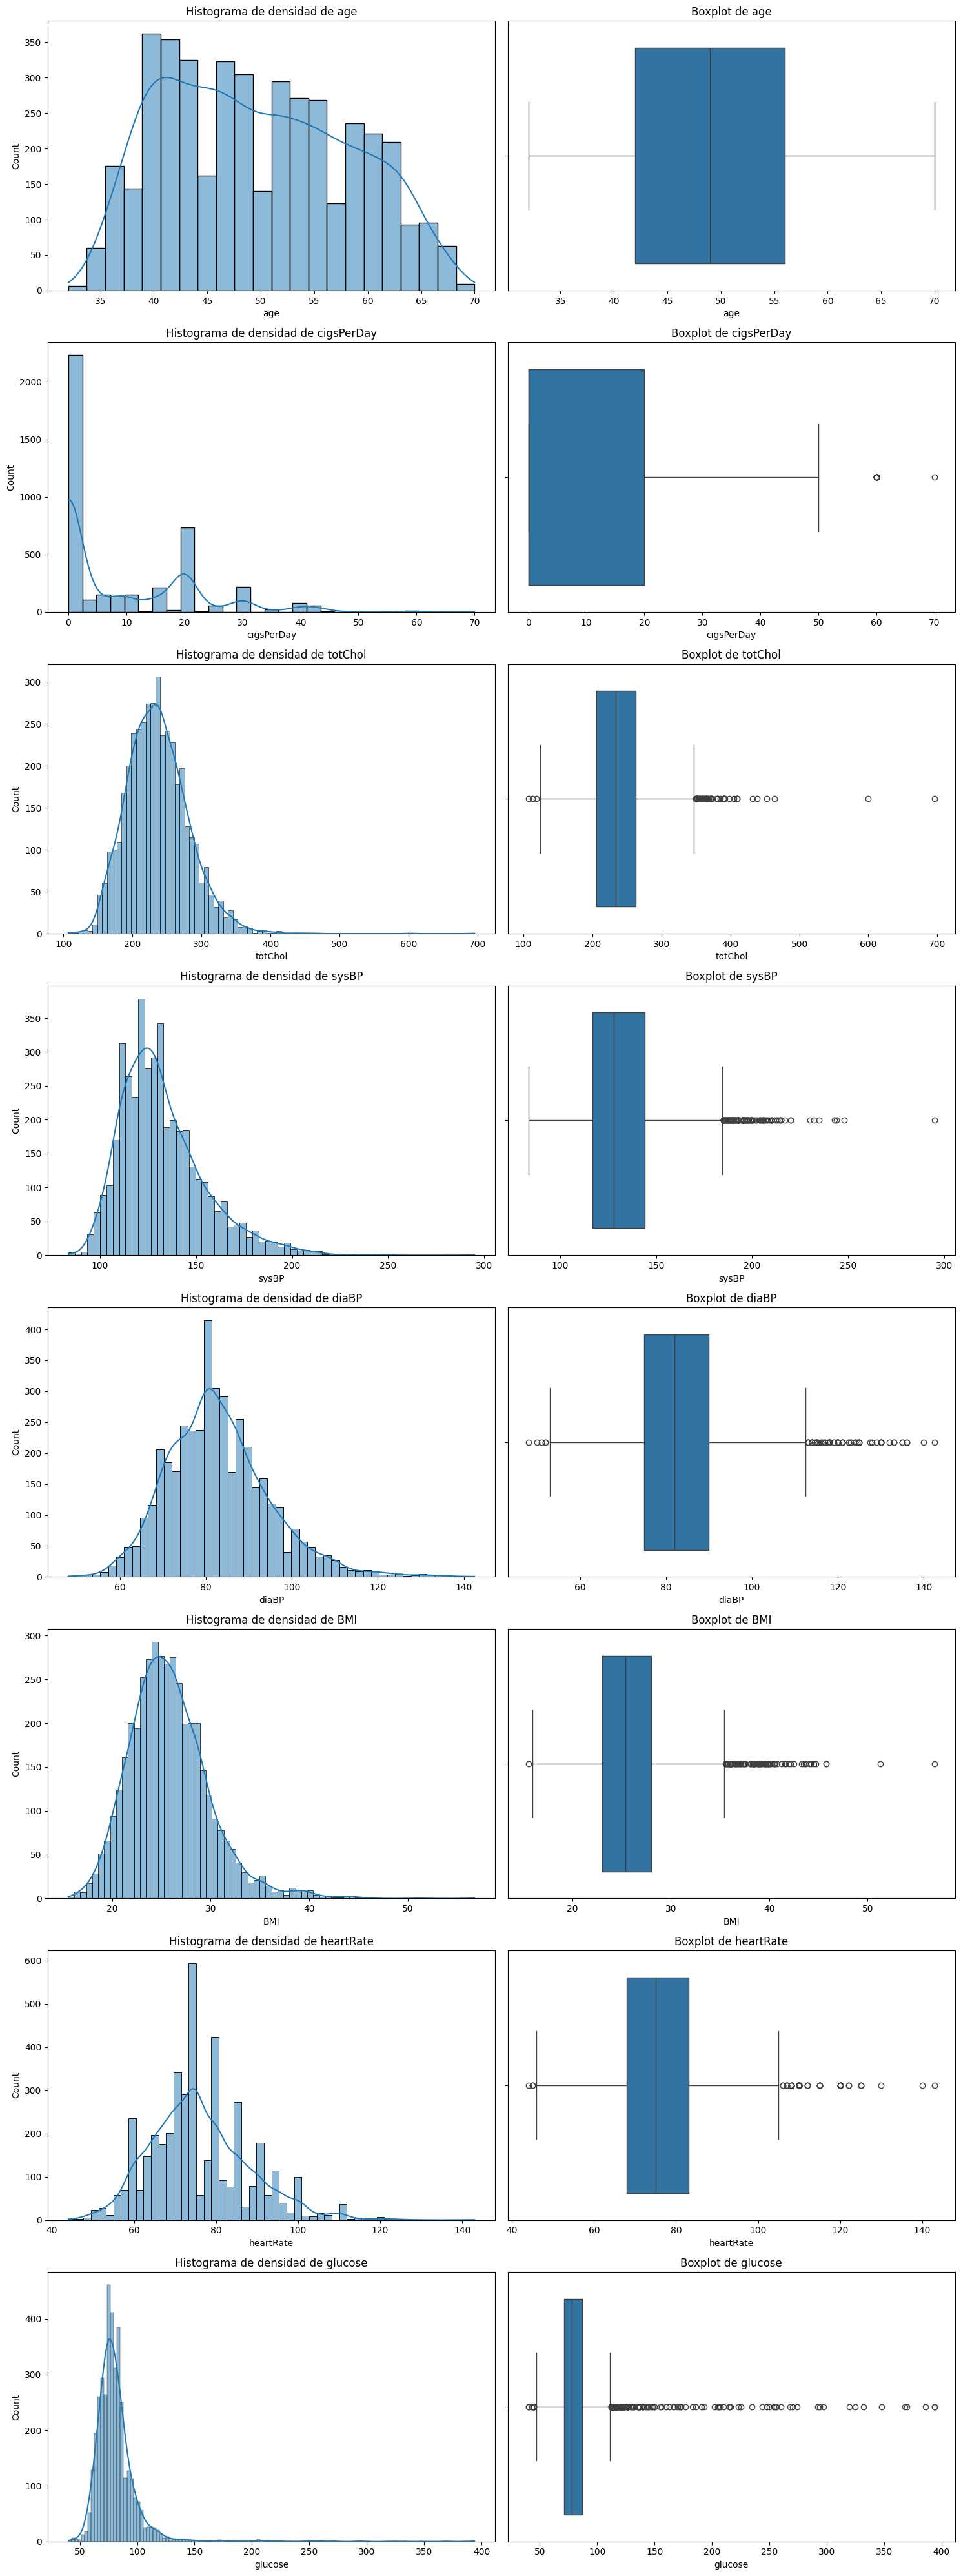

In [32]:
nrows = len(numeric_cols)
fig, axes = plt.subplots(nrows= nrows, ncols=2, figsize=(15, 5*nrows))

for i, column in enumerate(df_raw[numeric_cols]):
    # i = índice (0,1,2,3,4)  | column es lo mismo solo que para usarlo de diferente manera.
    #Histograma de densidad
    sns.histplot(df_raw[column],kde = True, ax=axes[i,0]) 
        # kde=True --> Dibuja una linea sobre las barras que ayuda a ver la "forma" de los datos.
        # ax=axes[i,0] --> Dibuja el histograma en la fila i, columna 0 (la izquierda).
    axes[i, 0].set_title(f'Histograma de densidad de {column}')

    #Boxplot
    sns.boxplot(x=df_raw[column], ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot de {column}")

plt.tight_layout()
plt.show()